## 00 — The Decision Function

We have four LOD files, each appropriate for a different zoom range. The decision function answers one question:

> *Given the current zoom level, which LOD file should we use?*

This sounds trivial — just an `if/elif` chain. But getting it right requires understanding:
1. What web map zoom levels actually mean in geographic terms
2. Where the transitions between levels should happen
3. How to prevent flicker when the user hovers near a transition boundary

## Web Map Zoom Levels

ipyleaflet (and all Web Mercator tile maps) use an integer zoom scale from 0 to 18+:

| Zoom | Viewport width (approximate) | Typical view |
|------|------------------------------|--------------|
| 0 | 360° (whole world) | Global |
| 2 | ~90° | Continental |
| 4 | ~22° | Large country |
| 6 | ~5° | Small country / region |
| 8 | ~1.4° | City + surroundings |
| 10 | ~0.35° | City district |
| 12 | ~0.09° | Neighborhood |
| 14 | ~0.02° | Street |

Each zoom level roughly **doubles the detail** — the viewport covers half the area of the previous level.

At zoom 0 we need a very coarse picture of the whole world. At zoom 12 we need fine detail for a small neighborhood. A single dataset cannot serve both well.

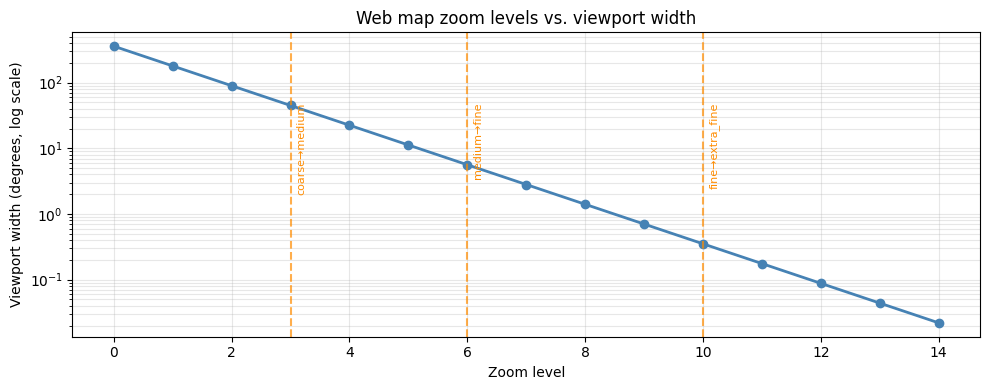

In [1]:
import matplotlib.pyplot as plt

# Approximate viewport width in degrees at each zoom level (for a standard display)
# At zoom 0 the full world is visible; each +1 zoom halves the width
zoom_levels = list(range(0, 15))
viewport_widths = [360 / (2 ** z) for z in zoom_levels]

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(zoom_levels, viewport_widths, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Zoom level')
ax.set_ylabel('Viewport width (degrees, log scale)')
ax.set_title('Web map zoom levels vs. viewport width')
ax.grid(True, which='both', alpha=0.3)

# Mark our LOD boundaries
for z, label in [(3, 'coarse→medium'), (6, 'medium→fine'), (10, 'fine→extra_fine')]:
    ax.axvline(z, color='darkorange', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.text(z + 0.1, 50, label, rotation=90, fontsize=8, color='darkorange', va='top')

plt.tight_layout()
plt.show()

## The Basic Decision Function

In [2]:
def get_lod(zoom):
    """
    Return the LOD level name for a given zoom level.
    """
    if zoom <= 3:
        return "coarse"
    elif zoom <= 6:
        return "medium"
    elif zoom <= 10:
        return "fine"
    else:
        return "extra_fine"

# Verify the mapping
print(f"{'Zoom':>6}  {'LOD Level':<12}")
print("-" * 22)
for z in range(0, 15):
    print(f"{z:>6}  {get_lod(z):<12}")

  Zoom  LOD Level   
----------------------
     0  coarse      
     1  coarse      
     2  coarse      
     3  coarse      
     4  medium      
     5  medium      
     6  medium      
     7  fine        
     8  fine        
     9  fine        
    10  fine        
    11  extra_fine  
    12  extra_fine  
    13  extra_fine  
    14  extra_fine  


## The Transition Flicker Problem

There is a subtle problem with this function. Imagine the user scrolls slowly and their zoom level oscillates between 6.8 and 7.2 as they find a comfortable view.

Each time the zoom crosses 7, the LOD switches — triggering a file query and layer swap. If the user is using a trackpad or mouse wheel, this can happen many times per second, causing visible flicker.

The solution is **hysteresis**: use different thresholds for switching up vs. switching back down.

```
Switch UP   (coarse → medium) at zoom 4
Switch DOWN (medium → coarse) at zoom 3

This creates a 1-zoom buffer zone where the LOD stays stable.
```

In [3]:
def get_lod_with_hysteresis(zoom, current_lod):
    """
    Return the LOD level for a zoom, with hysteresis to prevent flicker.
    Switch up at a higher threshold than switching down.
    """
    # Upgrade thresholds (zoom in — switch to more detail)
    if current_lod == "coarse"     and zoom >= 4:  return "medium"
    if current_lod == "medium"     and zoom >= 7:  return "fine"
    if current_lod == "fine"       and zoom >= 11: return "extra_fine"

    # Downgrade thresholds (zoom out — switch to less detail)
    if current_lod == "extra_fine" and zoom <= 9:  return "fine"
    if current_lod == "fine"       and zoom <= 5:  return "medium"
    if current_lod == "medium"     and zoom <= 2:  return "coarse"

    # No change needed
    return current_lod

In [4]:
# Simulate zooming in from 0 to 14, then back out
print("=== Zooming IN ===")
lod = "coarse"
for z in range(0, 15):
    new_lod = get_lod_with_hysteresis(z, lod)
    changed = " <- switch" if new_lod != lod else ""
    lod = new_lod
    print(f"  zoom {z:>2}  {lod:<12}{changed}")

print()
print("=== Zooming OUT ===")
lod = "extra_fine"
for z in range(14, -1, -1):
    new_lod = get_lod_with_hysteresis(z, lod)
    changed = " <- switch" if new_lod != lod else ""
    lod = new_lod
    print(f"  zoom {z:>2}  {lod:<12}{changed}")

=== Zooming IN ===
  zoom  0  coarse      
  zoom  1  coarse      
  zoom  2  coarse      
  zoom  3  coarse      
  zoom  4  medium       <- switch
  zoom  5  medium      
  zoom  6  medium      
  zoom  7  fine         <- switch
  zoom  8  fine        
  zoom  9  fine        
  zoom 10  fine        
  zoom 11  extra_fine   <- switch
  zoom 12  extra_fine  
  zoom 13  extra_fine  
  zoom 14  extra_fine  

=== Zooming OUT ===
  zoom 14  extra_fine  
  zoom 13  extra_fine  
  zoom 12  extra_fine  
  zoom 11  extra_fine  
  zoom 10  extra_fine  
  zoom  9  fine         <- switch
  zoom  8  fine        
  zoom  7  fine        
  zoom  6  fine        
  zoom  5  medium       <- switch
  zoom  4  medium      
  zoom  3  medium      
  zoom  2  coarse       <- switch
  zoom  1  coarse      
  zoom  0  coarse      


The switch-in and switch-out points are now different. A user hovering near zoom 6–7 will not trigger repeated layer swaps.

## Practical Note — ipyleaflet Zoom Values

ipyleaflet reports zoom as an integer when the user has stopped scrolling. During a pinch-to-zoom gesture on a touch device it can be a float.

Using `int(zoom)` or `math.floor(zoom)` before calling `get_lod` avoids any floating-point edge cases.

In [5]:
import math

def get_lod_safe(zoom, current_lod=None):
    """
    Get the LOD for a zoom level.
    Handles float zoom values and optionally applies hysteresis.
    """
    z = int(math.floor(zoom))
    if current_lod is not None:
        return get_lod_with_hysteresis(z, current_lod)
    return get_lod(z)

# Test with float zoom values
for z in [3.0, 3.5, 3.9, 4.0, 6.99, 7.01]:
    print(f"  zoom {z:.2f}  →  {get_lod_safe(z)}")

  zoom 3.00  →  coarse
  zoom 3.50  →  coarse
  zoom 3.90  →  coarse
  zoom 4.00  →  medium
  zoom 6.99  →  medium
  zoom 7.01  →  fine


## Exercise A

The transition thresholds in `get_lod_with_hysteresis` are hardcoded. Refactor it to accept a `thresholds` parameter — a dict that specifies upgrade and downgrade zoom values for each transition.

This makes the function reusable without editing its body.

In [9]:
# Refactor get_lod_with_hysteresis to accept a thresholds parameter
# Example structure:
thresholds = {
    "coarse":     {"up_at": 4},
    "medium":     {"up_at": 7,  "down_at": 2},
    "fine":       {"up_at": 11, "down_at": 5},
    "extra_fine": {             "down_at": 9},
}
# Your code here
def get_lod_with_hysteresis_thresh(zoom, current_lod, thresholds):

    # Upgrade (zoom in)
    if current_lod == "coarse":
        if zoom >= thresholds["coarse"]["up_at"]:
            return "medium"

    if current_lod == "medium":
        if zoom >= thresholds["medium"]["up_at"]:
            return "fine"

    if current_lod == "fine":
        if zoom >= thresholds["fine"]["up_at"]:
            return "extra_fine"

    # Downgrade (zoom out)
    if current_lod == "extra_fine":
        if zoom <= thresholds["extra_fine"]["down_at"]:
            return "fine"

    if current_lod == "fine":
        if zoom <= thresholds["fine"]["down_at"]:
            return "medium"

    if current_lod == "medium":
        if zoom <= thresholds["medium"]["down_at"]:
            return "coarse"

    # No change
    return current_lod

## Exercise B

Visualize the hysteresis. Plot two lines on the same chart:

1. The LOD level when zooming **in** from zoom 0 to 14 (encoded as 0=coarse, 1=medium, 2=fine, 3=extra_fine)
2. The LOD level when zooming **out** from zoom 14 to 0

The two lines should diverge at the transition zones — that gap is the hysteresis band.

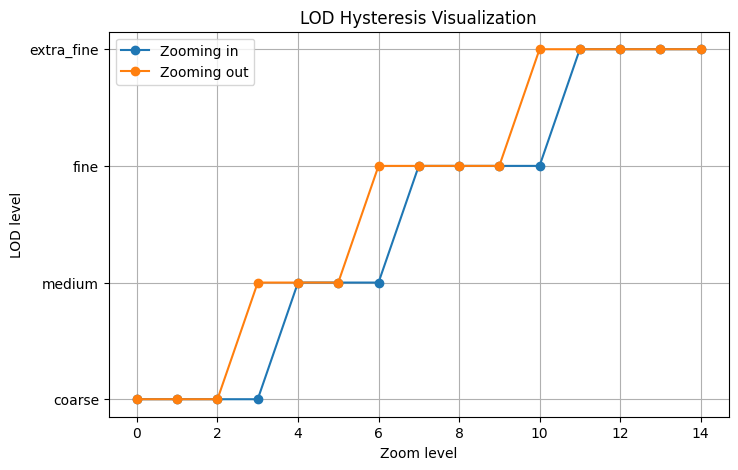

In [10]:
# Plot zoom-in vs zoom-out LOD trajectories to show the hysteresis band
# Your code here

import matplotlib.pyplot as plt

# thresholds from previous exercise
thresholds = {
    "coarse":     {"up_at": 4},
    "medium":     {"up_at": 7,  "down_at": 2},
    "fine":       {"up_at": 11, "down_at": 5},
    "extra_fine": {"down_at": 9},
}

# encode LODs as numbers
lod_to_int = {
    "coarse": 0,
    "medium": 1,
    "fine": 2,
    "extra_fine": 3
}

# --- simulate zooming IN ---
zoom_in_levels = []
lod = "coarse"

for z in range(0, 15):
    lod = get_lod_with_hysteresis_thresh(z, lod, thresholds)
    zoom_in_levels.append(lod_to_int[lod])

# --- simulate zooming OUT ---
zoom_out_levels = []
lod = "extra_fine"

for z in range(14, -1, -1):
    lod = get_lod_with_hysteresis(z, lod, thresholds)
    zoom_out_levels.append(lod_to_int[lod])

zoom_out_levels = zoom_out_levels[::-1]  # reverse to align with x-axis

# --- plot ---
zooms = list(range(0, 15))

plt.figure(figsize=(8, 5))
plt.plot(zooms, zoom_in_levels, label="Zooming in", marker='o')
plt.plot(zooms, zoom_out_levels, label="Zooming out", marker='o')

plt.yticks([0,1,2,3], ["coarse", "medium", "fine", "extra_fine"])
plt.xlabel("Zoom level")
plt.ylabel("LOD level")
plt.title("LOD Hysteresis Visualization")
plt.grid(True)
plt.legend()

plt.show()

## Check Your Understanding

The simple `get_lod(zoom)` function uses zoom level alone. A more sophisticated system might also consider **viewport size in pixels** — a larger monitor shows a wider area and might need more data than a small phone screen at the same zoom level.

Describe how you would modify `get_lod` to also accept a viewport width in degrees and use it to adjust the LOD decision. What new logic would be needed?

---

Of course, you would have to pass in the viewport width or something similar into the function. Based on this, you would decide if you need less detail (larger monitors and more map visible), or more detail (smaller monitors and less map visible). You could decide some arbitrary amount that factors into the zoom level and just add more if/else logic to accompany the original.

## Next

In [01 — Live Layer Switching](./01-Live_Layer_Switching.ipynb), we wire the decision function into a live map together with the grid index culling from Module 04.